# Notebook 06 — Feature Engineering & Preprocessing
**Project:** Climate-Driven Solar Energy Analytics
**Author:** BMSCE MCA Research Project

---

### Position in the pipeline

```
01_data_collection  →  02_data_understanding  →  03_seasonal_analysis
→  04_city_comparison  →  05_vif_outlier_analysis
→  [06_feature_engineering]  ← you are here
→  07_regression_models  →  08_xgboost  →  09_shap  →  10_recommender
```

### What this notebook does

This notebook bridges raw data to model-ready data. It has **five responsibilities**:

1. **Load & Reconstruct** — reload the master dataset and apply all decisions from Notebook 05
2. **Feature Engineering** — create `TEMP_RANGE`, `MONTH`, `SEASON`, `IS_MONSOON`, `log1p_PREC`
3. **Feature Selection** — lock in the Set C feature set confirmed by VIF Round 2
4. **Scaling** — apply `StandardScaler` (required for Ridge Regression; consistent across all models)
5. **Temporal Train/Test Split** — 2019–2022 train, 2023–2024 test (no data leakage)

### Key decisions carried forward from Notebook 05

| Decision | Detail |
|----------|--------|
| Drop | `T2M` — near-perfect linear combination of T2M_MAX and T2M_MIN |
| Drop | `T2M_MIN` — VIF Set B produced infinite values; Set C (without T2M_MIN) accepted |
| Keep | `T2M_MAX`, `TEMP_RANGE`, `RH2M`, `PS`, `WS10M`, `CLOUD_AMT`, `PRECTOTCORR` |
| No row deletion | Outlier rows carry fire-risk and grid-stress signal |
| Temporal split | 2019–2022 train / 2023–2024 test — weather is time-series data |


## Cell 1 — Imports & Project Constants

In [78]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.family':      'sans-serif',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
})
PALETTE = '#2563eb'

# ── Project constants (match notebooks 01–05 exactly) ────────────────────
RAW_DIR  = '../data/raw'
OUT_DIR  = '../outputs'
os.makedirs(OUT_DIR, exist_ok=True)

TARGET     = 'ALLSKY_SFC_SW_DWN'
SKIPROWS   = 17

CITY_NAMES = [
    'Ahmedabad', 'Bengaluru', 'Bhopal', 'Bhubaneswar', 'Chandigarh',
    'Chennai',   'Delhi',    'Guwahati', 'Hyderabad',  'Jaipur',
    'Kochi',     'Kolkata',  'Mangalore','Mumbai',     'Pune'
]

# IMD season classification (from notebook 03)
SEASON_MAP = {
    1: 'Winter',       2: 'Winter',      12: 'Winter',
    3: 'Pre-Monsoon',  4: 'Pre-Monsoon',  5: 'Pre-Monsoon',
    6: 'Monsoon',      7: 'Monsoon',      8: 'Monsoon',    9: 'Monsoon',
    10: 'Post-Monsoon', 11: 'Post-Monsoon'
}
SEASON_ORDER = ['Winter', 'Pre-Monsoon', 'Monsoon', 'Post-Monsoon']

# ── VIF-confirmed feature set from Notebook 05 (Set C) ───────────────────
# T2M dropped  : near-perfect linear combination → VIF infinite
# T2M_MIN dropped: in Set B (with TEMP_RANGE) → VIF infinite
# TEMP_RANGE added: engineered DTR predictor — independent, VIF < 5
FINAL_FEATURES = [
    'T2M_MAX',       # max daily temp — heat-wave signal, VIF < 5 in Set C
    'TEMP_RANGE',    # T2M_MAX - T2M_MIN — DTR predictor
    'RH2M',          # relative humidity — negative GHI predictor
    'PS',            # surface pressure — elevation proxy
    'WS10M',         # wind speed — cloud dispersal signal
    'CLOUD_AMT',     # cloud amount — strongest single GHI predictor
    'PRECTOTCORR',   # precipitation — monsoon signal
]

print('✓ Notebook 06 initialised')
print(f'  Final features : {FINAL_FEATURES}')
print(f'  Target         : {TARGET}')
print(f'  Cities         : {len(CITY_NAMES)}')


✓ Notebook 06 initialised
  Final features : ['T2M_MAX', 'TEMP_RANGE', 'RH2M', 'PS', 'WS10M', 'CLOUD_AMT', 'PRECTOTCORR']
  Target         : ALLSKY_SFC_SW_DWN
  Cities         : 15


## Cell 2 — Load & Merge All 15 City CSVs

Exact loading pattern from Notebooks 01–05: explicit `CITY_NAMES` list, `skiprows=17`, `-999` treated as NaN.

In [79]:
dfs = []

for city in CITY_NAMES:
    path = os.path.join(RAW_DIR, f'{city}.csv')
    df   = pd.read_csv(path, skiprows=SKIPROWS, na_values=['-999', -999])

    df['date'] = pd.to_datetime(
        df['YEAR'].astype(str) + '-'
        + df['MO'].astype(str).str.zfill(2) + '-'
        + df['DY'].astype(str).str.zfill(2)
    )
    df['city'] = city
    dfs.append(df)

master = pd.concat(dfs, ignore_index=True)
master = master.sort_values(['city', 'date']).reset_index(drop=True)

# Retain only useful raw columns
raw_cols = ['date', 'city', 'T2M', 'T2M_MAX', 'T2M_MIN',
            'RH2M', 'PS', 'WS10M', 'CLOUD_AMT', 'PRECTOTCORR', TARGET]
master = master[[c for c in raw_cols if c in master.columns]]

print(f'Master shape   : {master.shape}')
print(f'Cities         : {master["city"].nunique()}')
print(f'Date range     : {master["date"].min().date()} → {master["date"].max().date()}')
print(f'Missing values : {master.isnull().sum().sum()}')
master.head(3)


Master shape   : (32880, 11)
Cities         : 15
Date range     : 2019-01-01 → 2024-12-31
Missing values : 0


,date,city,T2M,T2M_MAX,T2M_MIN,RH2M,PS,WS10M,CLOUD_AMT,PRECTOTCORR,ALLSKY_SFC_SW_DWN
0,2019-01-01,Ahmedabad,20.11,31.21,10.91,12.37,101.27,2.60,0.37,0.0,4.7508
1,2019-01-02,Ahmedabad,20.46,31.36,11.56,13.13,101.26,2.87,0.18,0.0,4.8002
2,2019-01-03,Ahmedabad,19.71,30.61,10.84,18.30,101.39,3.04,3.71,0.0,4.8130


## Cell 3 — Drop NaN Rows & Record Count

We drop rows with missing values in ANY model-relevant column. Notebook 05 confirmed the
count was negligible (< 0.1 %). We record the before/after so this is reproducible.


In [80]:
model_cols = ['T2M_MAX', 'T2M_MIN', 'RH2M', 'PS',
              'WS10M', 'CLOUD_AMT', 'PRECTOTCORR', TARGET]

before  = len(master)
df_work = master.dropna(subset=model_cols).copy()
after   = len(df_work)

print(f'Rows before NaN drop : {before:,}')
print(f'Rows dropped         : {before - after:,}  ({(before - after)/before*100:.3f}%)')
print(f'Rows remaining       : {after:,}')
print()
print('No rows deleted for outliers — confirmed in Notebook 05.')
print('Outlier rows carry fire-risk and grid-stress labels.')


Rows before NaN drop : 32,880
Rows dropped         : 0  (0.000%)
Rows remaining       : 32,880

No rows deleted for outliers — confirmed in Notebook 05.
Outlier rows carry fire-risk and grid-stress labels.


## Cell 4 — Feature Engineering

### 4a. TEMP_RANGE (confirmed in Notebook 05)

**Diurnal Temperature Range** = `T2M_MAX − T2M_MIN`

Physical basis (Hargreaves & Samani, 1982):
- Large DTR → clear sky, low humidity, high GHI
- Small DTR → overcast / monsoon, low GHI

VIF in Set C (Notebook 05): **< 5** ✓


In [81]:
# ── 4a. TEMP_RANGE ───────────────────────────────────────────────────────
df_work['TEMP_RANGE'] = (
    df_work['T2M_MAX'] - df_work['T2M_MIN']
)

# Notebook 05 VIF decision:
# T2M_MIN is used only to create TEMP_RANGE
# and must not be passed to any model.
df_work.drop(columns=['T2M_MIN'], inplace=True)

assert 'T2M_MIN' not in df_work.columns

r_tr = df_work[['TEMP_RANGE', TARGET]].corr().iloc[0, 1]


# ── 4f. WIND_CLOUD interaction ────────────────────────────────────────────
# Physical basis: wind speed affects cloud dispersal and transport.
# Higher wind + high cloud cover → unstable, rapidly changing radiation.
# This interaction captures combined atmospheric dynamics not present in
# either variable alone.
df_work['WIND_CLOUD'] = df_work['WS10M'] * df_work['CLOUD_AMT']

r_wc = df_work[['WIND_CLOUD', TARGET]].corr().iloc[0, 1]
print(f'WIND_CLOUD created  : WS10M × CLOUD_AMT')
print(f'  Min  : {df_work["WIND_CLOUD"].min():.2f}')
print(f'  Max  : {df_work["WIND_CLOUD"].max():.2f}')
print(f'  Mean : {df_work["WIND_CLOUD"].mean():.2f}')
print(f'  r with {TARGET}: {r_wc:.3f}')

WIND_CLOUD created  : WS10M × CLOUD_AMT
  Min  : 0.00
  Max  : 1472.79
  Mean : 180.77
  r with ALLSKY_SFC_SW_DWN: -0.380


### 4b. Time Features — MONTH, YEAR, DAY_OF_YEAR, SEASON, IS_MONSOON

Month and season were identified as important cyclical features in Notebook 03. The year-month heatmap confirmed a consistent annual pattern across all 6 years.

In [82]:
# ── 4b. Time features ────────────────────────────────────────────────────
df_work['MONTH']      = df_work['date'].dt.month
df_work['YEAR_NUM']   = df_work['date'].dt.year
df_work['DAY_OF_YEAR']= df_work['date'].dt.dayofyear
df_work['SEASON']     = df_work['MONTH'].map(SEASON_MAP)
df_work['IS_MONSOON'] = (df_work['SEASON'] == 'Monsoon').astype(int)

print('Time features created:')
print(f'  MONTH range      : {df_work["MONTH"].min()} – {df_work["MONTH"].max()}')
print(f'  YEAR_NUM range   : {df_work["YEAR_NUM"].min()} – {df_work["YEAR_NUM"].max()}')
print(f'  IS_MONSOON dist  : {df_work["IS_MONSOON"].value_counts().to_dict()}')
print()
print('Season distribution:')
print(df_work["SEASON"].value_counts().reindex(SEASON_ORDER))


Time features created:
  MONTH range      : 1 – 12
  YEAR_NUM range   : 2019 – 2024
  IS_MONSOON dist  : {0: 21900, 1: 10980}

Season distribution:
SEASON
Winter           8130
Pre-Monsoon      8280
Monsoon         10980
Post-Monsoon     5490
Name: count, dtype: int64


### 4c. log1p(PRECTOTCORR) — Handle Right-Skewed Rainfall

Precipitation is strongly right-skewed (identified in Notebook 02). The `log1p` transform (log(1+x)) compresses the tail while handling zero-rain days correctly.

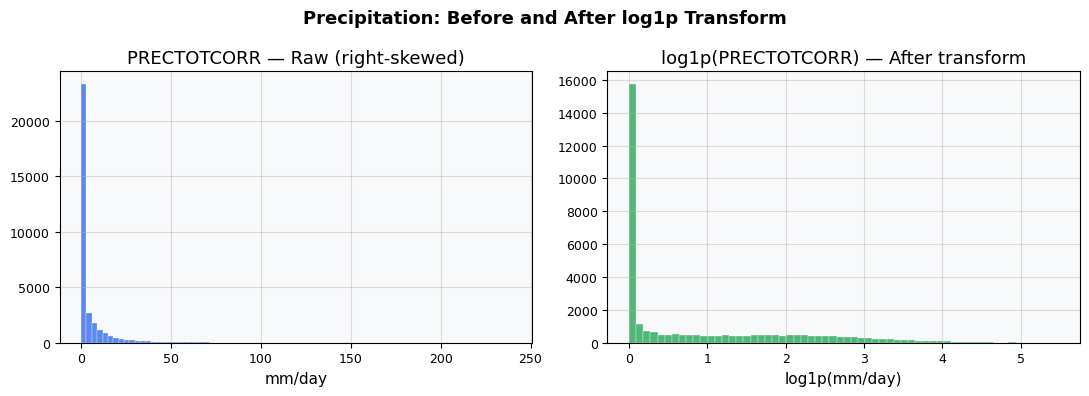

Skewness before : 5.060
Skewness after  : 1.141
Skewness reduced by 77.4%


In [83]:
# ── 4c. Log-transform precipitation ──────────────────────────────────────
df_work['log1p_PREC'] = np.log1p(df_work['PRECTOTCORR'])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df_work['PRECTOTCORR'], bins=80, color=PALETTE, alpha=0.75,
             edgecolor='white', linewidth=0.3)
axes[0].set_title('PRECTOTCORR — Raw (right-skewed)')
axes[0].set_xlabel('mm/day')

axes[1].hist(df_work['log1p_PREC'], bins=60, color='#16a34a', alpha=0.75,
             edgecolor='white', linewidth=0.3)
axes[1].set_title('log1p(PRECTOTCORR) — After transform')
axes[1].set_xlabel('log1p(mm/day)')

plt.suptitle('Precipitation: Before and After log1p Transform', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'prec_log_transform.png'), dpi=150, bbox_inches='tight')
plt.show()

skew_raw  = df_work['PRECTOTCORR'].skew()
skew_log  = df_work['log1p_PREC'].skew()
print(f'Skewness before : {skew_raw:.3f}')
print(f'Skewness after  : {skew_log:.3f}')
print(f'Skewness reduced by {abs(skew_raw - skew_log) / abs(skew_raw) * 100:.1f}%')


### 4d. Cyclical Encoding of MONTH

Month 1 and Month 12 are consecutive in the calendar but 11 apart numerically. Sine/cosine encoding wraps the month axis into a circle so the model sees January and December as close together.

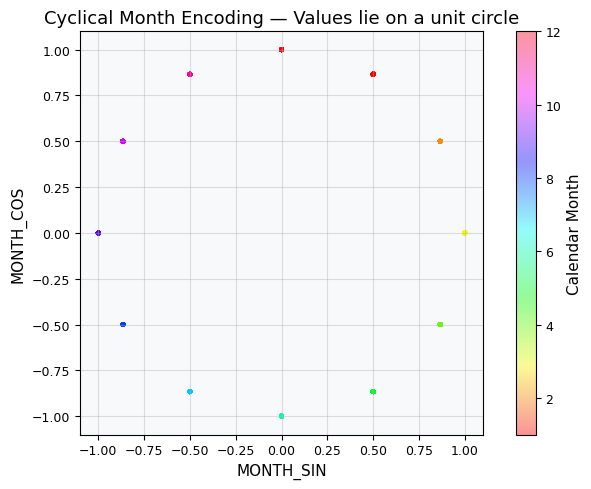

Cyclical encoding created: MONTH_SIN, MONTH_COS
Month 1 (Jan) and Month 12 (Dec) are now adjacent in this space.


In [84]:
# ── 4d. Cyclical month encoding ──────────────────────────────────────────
df_work['MONTH_SIN'] = np.sin(2 * np.pi * df_work['MONTH'] / 12)
df_work['MONTH_COS'] = np.cos(2 * np.pi * df_work['MONTH'] / 12)

# Verify the encoding wraps correctly
fig, ax = plt.subplots(figsize=(7, 5))
sample = df_work[df_work['city'] == 'Bengaluru'].sort_values('date')
sc = ax.scatter(sample['MONTH_SIN'], sample['MONTH_COS'],
                c=sample['MONTH'], cmap='hsv', s=6, alpha=0.4)
plt.colorbar(sc, ax=ax, label='Calendar Month')
ax.set_xlabel('MONTH_SIN')
ax.set_ylabel('MONTH_COS')
ax.set_title('Cyclical Month Encoding — Values lie on a unit circle')
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'month_cyclical_encoding.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Cyclical encoding created: MONTH_SIN, MONTH_COS')
print('Month 1 (Jan) and Month 12 (Dec) are now adjacent in this space.')


In [85]:
# ── 4e. City Encoding ─────────────────────────────────────────────

city_dummies = pd.get_dummies(
    df_work['city'],
    prefix='CITY',
    dtype=int
)

df_work = pd.concat(
    [df_work, city_dummies],
    axis=1
)

CITY_FEATURES = sorted(
    [c for c in city_dummies.columns]
)

print(f'City features created: {len(CITY_FEATURES)}')
print(CITY_FEATURES)

City features created: 15
['CITY_Ahmedabad', 'CITY_Bengaluru', 'CITY_Bhopal', 'CITY_Bhubaneswar', 'CITY_Chandigarh', 'CITY_Chennai', 'CITY_Delhi', 'CITY_Guwahati', 'CITY_Hyderabad', 'CITY_Jaipur', 'CITY_Kochi', 'CITY_Kolkata', 'CITY_Mangalore', 'CITY_Mumbai', 'CITY_Pune']


### 4g. Lag Features & Rolling Mean

**Why before the split:** Lag features use `groupby('city').shift()` on the full dataset so the boundary row (first day of the test set) can correctly look back into train-period history. Creating lags after splitting would produce NaN at the boundary and lose that cross-boundary signal.

**City-wise groupby:** Essential — without it, the last day of city A's data would become the "previous day" for city B's first row.

| Feature | Formula | Physical meaning |
|---------|---------|------------------|
| `GHI_LAG1` | GHI shifted 1 day (city-wise) | Yesterday's radiation — weather persistence |
| `RH2M_LAG1` | RH2M shifted 1 day (city-wise) | Yesterday's humidity — moisture memory |
| `CLOUD_LAG1` | CLOUD_AMT shifted 1 day (city-wise) | Cloud system persistence |
| `GHI_7DAY_MEAN` | 7-day rolling mean GHI (city-wise) | Medium-term weather pattern smoothing |

In [86]:
# ── 4g. City-wise lag features ───────────────────────────────────────────
# df_work is already sorted by ['city', 'date'] from Cell 2.
# groupby('city') ensures lags never cross city boundaries.

df_work['GHI_LAG1'] = (
    df_work.groupby('city')['ALLSKY_SFC_SW_DWN']
           .shift(1)
)

df_work['RH2M_LAG1'] = (
    df_work.groupby('city')['RH2M']
           .shift(1)
)

df_work['CLOUD_LAG1'] = (
    df_work.groupby('city')['CLOUD_AMT']
           .shift(1)
)

# ── 4h. 7-day rolling mean GHI ───────────────────────────────────────────
# min_periods=1 means we get a value even for the first few days of each city
# (based on however many rows are available), avoiding unnecessary NaN rows.
df_work['GHI_7DAY_MEAN'] = (
    df_work.groupby('city')['ALLSKY_SFC_SW_DWN']
           .transform(lambda x: x.rolling(7, min_periods=1).mean())
)

# ── 4i. Handle NaN rows created by lag shift(1) ──────────────────────────
# shift(1) produces NaN only for the very first row of each city (15 rows total).
# min_periods=1 on rolling means GHI_7DAY_MEAN has NO additional NaN rows.
# We drop only lag-column NaN rows — not a blanket dropna() — to keep the
# count auditable and avoid accidentally removing unrelated NaN rows.
lag_cols = ['GHI_LAG1', 'RH2M_LAG1', 'CLOUD_LAG1']

before_lag_drop = len(df_work)
print(f'Rows before lag NaN drop : {before_lag_drop:,}')

df_work = df_work.dropna(subset=lag_cols).reset_index(drop=True)

after_lag_drop  = len(df_work)
rows_dropped    = before_lag_drop - after_lag_drop
print(f'Rows dropped             : {rows_dropped}  (expected: {df_work["city"].nunique()} — one per city)')
print(f'Rows remaining           : {after_lag_drop:,}')
print()

# Sanity check: dropped exactly one row per city
assert rows_dropped == df_work['city'].nunique(), (
    f'Expected {df_work["city"].nunique()} rows dropped, got {rows_dropped}'
)

print('Lag & rolling features created:')
for feat in ['GHI_LAG1', 'RH2M_LAG1', 'CLOUD_LAG1', 'GHI_7DAY_MEAN']:
    r = df_work[[feat, TARGET]].corr().iloc[0, 1]
    null_count = df_work[feat].isnull().sum()
    print(f'  {feat:<16}  r={r:+.3f}  nulls={null_count}')

print()
print('✓ No NaN remaining in lag/rolling columns')
print('✓ City boundaries preserved (groupby city)')

Rows before lag NaN drop : 32,880
Rows dropped             : 15  (expected: 15 — one per city)
Rows remaining           : 32,865

Lag & rolling features created:
  GHI_LAG1          r=+0.777  nulls=0
  RH2M_LAG1         r=-0.463  nulls=0
  CLOUD_LAG1        r=-0.341  nulls=0
  GHI_7DAY_MEAN     r=+0.796  nulls=0

✓ No NaN remaining in lag/rolling columns
✓ City boundaries preserved (groupby city)


## Cell 5 — Final Feature Set Definition

We lock in two model variants for Notebooks 07–09:

| Variant | Features | Use |
|---------|----------|-----|
| **Core** | VIF Set C + log1p_PREC | Regression & XGBoost |
| **Extended** | Core + MONTH_SIN, MONTH_COS, IS_MONSOON, DAY_OF_YEAR | Time-aware models |

In [87]:
# ── CORE feature set (from VIF Set C + log-transformed precipitation) ────
FEATURES_CORE = [
    'T2M_MAX',
    'TEMP_RANGE',
    'RH2M',
    'PS',
    'WS10M',
    'CLOUD_AMT',
    'log1p_PREC',   # replaces raw PRECTOTCORR
    'WIND_CLOUD',   # WS10M × CLOUD_AMT — wind–cloud interaction
]

# ── TEMPORAL feature set (cyclical + binary season indicators) ─────────────
FEATURES_TEMPORAL = [
    'MONTH_SIN',
    'MONTH_COS',
    'IS_MONSOON',
    'DAY_OF_YEAR',
]

# ── LAG & ROLLING feature set (created before split — see Cell 5b) ─────────
# These require city-wise sorting and must only be added to EXTENDED.
# Do not add to FEATURES_CORE — lag features require temporal ordering
# and are not available for naive baselines.
FEATURES_LAG = [
    'GHI_LAG1',       # GHI previous day (city-wise)
    'RH2M_LAG1',      # Humidity previous day (city-wise)
    'CLOUD_LAG1',     # Cloud cover previous day (city-wise)
    'GHI_7DAY_MEAN',  # 7-day rolling mean GHI (city-wise)
]

# ── EXTENDED feature set (full context — used by XGBoost, SHAP) ────────────
FEATURES_EXTENDED = (
    FEATURES_CORE
    + FEATURES_TEMPORAL
    + FEATURES_LAG
    + CITY_FEATURES
)

print('FEATURES_CORE    :', FEATURES_CORE)
print(f'                   ({len(FEATURES_CORE)} features)')
print()
print('FEATURES_TEMPORAL:', FEATURES_TEMPORAL)
print(f'                   ({len(FEATURES_TEMPORAL)} features)')
print()
print('FEATURES_LAG     :', FEATURES_LAG)
print(f'                   ({len(FEATURES_LAG)} features)')
print()
print(f'CITY_FEATURES    : {len(CITY_FEATURES)} one-hot columns')
print()
print(f'FEATURES_EXTENDED: {len(FEATURES_EXTENDED)} total')

# ── Verify all features exist in df_work ──────────────────────────────────
missing_features = [f for f in FEATURES_EXTENDED if f not in df_work.columns]

for f in FEATURES_EXTENDED:
    status = '✓' if f in df_work.columns else '✗ MISSING'
    print(f'  {status}  {f}')

assert len(missing_features) == 0, f"Missing features: {missing_features}"


print()
print("Verification Checks")
assert 'T2M_MIN' not in FEATURES_EXTENDED
assert 'T2M_MIN' not in df_work.columns
assert 'WIND_CLOUD' in FEATURES_CORE
assert 'GHI_LAG1'   in FEATURES_LAG
assert 'RISK_LABEL' not in FEATURES_CORE
assert 'RISK_LABEL' not in FEATURES_EXTENDED
print("✓ T2M_MIN removed (NB05 VIF decision)")
print("✓ WIND_CLOUD in FEATURES_CORE")
print("✓ Lag features in FEATURES_LAG / FEATURES_EXTENDED only")
print("✓ RISK_LABEL not in any feature list (it is a target, not a predictor)")
print("✓ City encoding included")

FEATURES_CORE    : ['T2M_MAX', 'TEMP_RANGE', 'RH2M', 'PS', 'WS10M', 'CLOUD_AMT', 'log1p_PREC', 'WIND_CLOUD']
                   (8 features)

FEATURES_TEMPORAL: ['MONTH_SIN', 'MONTH_COS', 'IS_MONSOON', 'DAY_OF_YEAR']
                   (4 features)

FEATURES_LAG     : ['GHI_LAG1', 'RH2M_LAG1', 'CLOUD_LAG1', 'GHI_7DAY_MEAN']
                   (4 features)

CITY_FEATURES    : 15 one-hot columns

FEATURES_EXTENDED: 31 total
  ✓  T2M_MAX
  ✓  TEMP_RANGE
  ✓  RH2M
  ✓  PS
  ✓  WS10M
  ✓  CLOUD_AMT
  ✓  log1p_PREC
  ✓  WIND_CLOUD
  ✓  MONTH_SIN
  ✓  MONTH_COS
  ✓  IS_MONSOON
  ✓  DAY_OF_YEAR
  ✓  GHI_LAG1
  ✓  RH2M_LAG1
  ✓  CLOUD_LAG1
  ✓  GHI_7DAY_MEAN
  ✓  CITY_Ahmedabad
  ✓  CITY_Bengaluru
  ✓  CITY_Bhopal
  ✓  CITY_Bhubaneswar
  ✓  CITY_Chandigarh
  ✓  CITY_Chennai
  ✓  CITY_Delhi
  ✓  CITY_Guwahati
  ✓  CITY_Hyderabad
  ✓  CITY_Jaipur
  ✓  CITY_Kochi
  ✓  CITY_Kolkata
  ✓  CITY_Mangalore
  ✓  CITY_Mumbai
  ✓  CITY_Pune

Verification Checks
✓ T2M_MIN removed (NB05 VIF decision)
✓ WIND_

### 4g. Lag Features & Rolling Mean

**Why before the split:** Lag features use `groupby('city').shift()` on the full dataset so the boundary row (first day of the test set) can correctly look back into train-period history. Creating lags after splitting would produce NaN at the boundary and lose that cross-boundary signal.

**City-wise groupby:** Essential — without it, the last day of city A's data would become the "previous day" for city B's first row.

| Feature | Formula | Physical meaning |
|---------|---------|------------------|
| `GHI_LAG1` | GHI shifted 1 day (city-wise) | Yesterday's radiation — weather persistence |
| `RH2M_LAG1` | RH2M shifted 1 day (city-wise) | Yesterday's humidity — moisture memory |
| `CLOUD_LAG1` | CLOUD_AMT shifted 1 day (city-wise) | Cloud system persistence |
| `GHI_7DAY_MEAN` | 7-day rolling mean GHI (city-wise) | Medium-term weather pattern smoothing |

In [88]:
# # ── 4g. City-wise lag features ───────────────────────────────────────────
# # df_work is already sorted by ['city', 'date'] from Cell 2.
# # groupby('city') ensures lags never cross city boundaries.

# df_work['GHI_LAG1'] = (
#     df_work.groupby('city')['ALLSKY_SFC_SW_DWN']
#            .shift(1)
# )

# df_work['RH2M_LAG1'] = (
#     df_work.groupby('city')['RH2M']
#            .shift(1)
# )

# df_work['CLOUD_LAG1'] = (
#     df_work.groupby('city')['CLOUD_AMT']
#            .shift(1)
# )

# # ── 4h. 7-day rolling mean GHI ───────────────────────────────────────────
# # min_periods=1 means we get a value even for the first few days of each city
# # (based on however many rows are available), avoiding unnecessary NaN rows.
# df_work['GHI_7DAY_MEAN'] = (
#     df_work.groupby('city')['ALLSKY_SFC_SW_DWN']
#            .transform(lambda x: x.rolling(7, min_periods=1).mean())
# )

# # ── 4i. Handle NaN rows created by lag shift(1) ──────────────────────────
# # shift(1) produces NaN only for the very first row of each city (15 rows total).
# # min_periods=1 on rolling means GHI_7DAY_MEAN has NO additional NaN rows.
# # We drop only lag-column NaN rows — not a blanket dropna() — to keep the
# # count auditable and avoid accidentally removing unrelated NaN rows.
# lag_cols = ['GHI_LAG1', 'RH2M_LAG1', 'CLOUD_LAG1']

# before_lag_drop = len(df_work)
# print(f'Rows before lag NaN drop : {before_lag_drop:,}')

# df_work = df_work.dropna(subset=lag_cols).reset_index(drop=True)

# after_lag_drop  = len(df_work)
# rows_dropped    = before_lag_drop - after_lag_drop
# print(f'Rows dropped             : {rows_dropped}  (expected: {df_work["city"].nunique()} — one per city)')
# print(f'Rows remaining           : {after_lag_drop:,}')
# print()

# # Sanity check: dropped exactly one row per city
# assert rows_dropped == df_work['city'].nunique(), (
#     f'Expected {df_work["city"].nunique()} rows dropped, got {rows_dropped}'
# )

# print('Lag & rolling features created:')
# for feat in ['GHI_LAG1', 'RH2M_LAG1', 'CLOUD_LAG1', 'GHI_7DAY_MEAN']:
#     r = df_work[[feat, TARGET]].corr().iloc[0, 1]
#     null_count = df_work[feat].isnull().sum()
#     print(f'  {feat:<16}  r={r:+.3f}  nulls={null_count}')

# print()
# print('✓ No NaN remaining in lag/rolling columns')
# print('✓ City boundaries preserved (groupby city)')

### 4j. Risk Classification Target (`RISK_LABEL`)

`RISK_LABEL` is the classification **target** for the SVM / Random Forest classifier in Notebooks 08–09. It is **not** a predictor and must never appear in `FEATURES_CORE` or `FEATURES_EXTENDED`.

| Label | Value | Condition | Interpretation |
|-------|-------|-----------|----------------|
| Normal | 0 | default | Standard solar day |
| Grid Stress | 1 | `CLOUD_AMT > 80` | Sudden heavy cloud cover — rapid GHI drop risks grid frequency instability |
| Fire Risk | 2 | `T2M_MAX > 42` AND `RH2M < 18` AND `GHI > 5.5` | Extreme heat + bone-dry air + high radiation |

**Threshold note:** `ALLSKY_SFC_SW_DWN > 5.5` corresponds to ~650 W/m² averaged over a full day, which is the standard extreme-radiation threshold in kWh/m²/day (NASA POWER units). Priority: Fire Risk (2) overrides Grid Stress (1) when both conditions are met.

In [89]:
# ── 4j. Risk Classification Target ───────────────────────────────────────
# Priority: Fire Risk (2) is checked first; Grid Stress (1) is checked only
# when the row is not already Fire Risk. np.select applies conditions in order
# and assigns the first matching choice.
#
# ALLSKY_SFC_SW_DWN is in kWh/m²/day (NASA POWER units).
# Threshold 5.5 kWh/m²/day ≈ 650 W/m² averaged over a full solar day.

conditions = [
    (df_work['T2M_MAX']            > 42 ) &
    (df_work['RH2M']               < 18 ) &
    (df_work['ALLSKY_SFC_SW_DWN']  > 5.5),   # Fire Risk

    (df_work['CLOUD_AMT']          > 80 ),    # Grid Stress
]

choices = [2, 1]

df_work['RISK_LABEL'] = np.select(conditions, choices, default=0)

# ── Distribution summary ──────────────────────────────────────────────────
counts = df_work['RISK_LABEL'].value_counts().sort_index()
label_map = {0: 'Normal', 1: 'Grid Stress', 2: 'Fire Risk'}

print('RISK_LABEL distribution:')
for code, count in counts.items():
    pct = count / len(df_work) * 100
    bar = '█' * max(1, int(pct / 2))
    print(f'  {code} ({label_map[code]:<12}) : {count:>6,}  ({pct:5.1f}%)  {bar}')

print()
print('RISK_LABEL by city (Fire Risk days):')
fire_by_city = (
    df_work[df_work['RISK_LABEL'] == 2]
    .groupby('city')
    .size()
    .sort_values(ascending=False)
)
for city, cnt in fire_by_city.items():
    print(f'  {city:<20} {cnt} days')

print()
# RISK_LABEL must NOT be in any feature list
assert 'RISK_LABEL' not in FEATURES_CORE,     'FATAL: RISK_LABEL in FEATURES_CORE!'
assert 'RISK_LABEL' not in FEATURES_EXTENDED,  'FATAL: RISK_LABEL in FEATURES_EXTENDED!'
print('✓ RISK_LABEL is a classification target — confirmed absent from feature lists')
print('✓ Use RISK_LABEL as y_classification in NB08 classification pipeline')

RISK_LABEL distribution:
  0 (Normal      ) : 22,284  ( 67.8%)  █████████████████████████████████
  1 (Grid Stress ) : 10,352  ( 31.5%)  ███████████████
  2 (Fire Risk   ) :    229  (  0.7%)  █

RISK_LABEL by city (Fire Risk days):
  Delhi                76 days
  Jaipur               60 days
  Bhopal               39 days
  Chandigarh           33 days
  Ahmedabad            18 days
  Hyderabad            3 days

✓ RISK_LABEL is a classification target — confirmed absent from feature lists
✓ Use RISK_LABEL as y_classification in NB08 classification pipeline


## Cell 6 — Temporal Train / Test Split

### Why temporal split — NOT random split

Our data is a **time series**. A random split would allow the model to train on
observations from 2023 and then be tested on observations from 2021 — this constitutes
**data leakage**: the model learns future patterns that wouldn't be available in deployment.

**Split boundary:**
- **Train:** 2019–2022 (4 years, ~80% of data)
- **Test:** 2023–2024 (2 years, ~20% of data)

This mirrors real-world deployment: you train on historical data and predict for the next period.


In [90]:
TRAIN_YEARS = [2019, 2020, 2021, 2022]
TEST_YEARS  = [2023, 2024]

mask_train = df_work['YEAR_NUM'].isin(TRAIN_YEARS)
mask_test  = df_work['YEAR_NUM'].isin(TEST_YEARS)

train_df = df_work[mask_train].copy()
test_df  = df_work[mask_test].copy()

print(f'Train set : {len(train_df):,} rows  | Years: {TRAIN_YEARS}')
print(f'Test set  : {len(test_df):,} rows   | Years: {TEST_YEARS}')
print(f'Train %   : {len(train_df)/len(df_work)*100:.1f}%')
print(f'Test %    : {len(test_df)/len(df_work)*100:.1f}%')
print()

# Verify no date overlap
assert train_df['date'].max() < test_df['date'].min(), 'Date overlap detected!'
print(f'Train ends   : {train_df["date"].max().date()}')
print(f'Test starts  : {test_df["date"].min().date()}')
print('✓ No temporal overlap confirmed')


Train set : 21,900 rows  | Years: [2019, 2020, 2021, 2022]
Test set  : 10,965 rows   | Years: [2023, 2024]
Train %   : 66.6%
Test %    : 33.4%

Train ends   : 2022-12-31
Test starts  : 2023-01-01
✓ No temporal overlap confirmed


## Cell 7 — Verify Split Preserves Season Distribution

If the split were skewed (e.g. test set has more monsoon months), performance metrics would be misleading. We check that all four Indian seasons are proportionally represented in both sets.

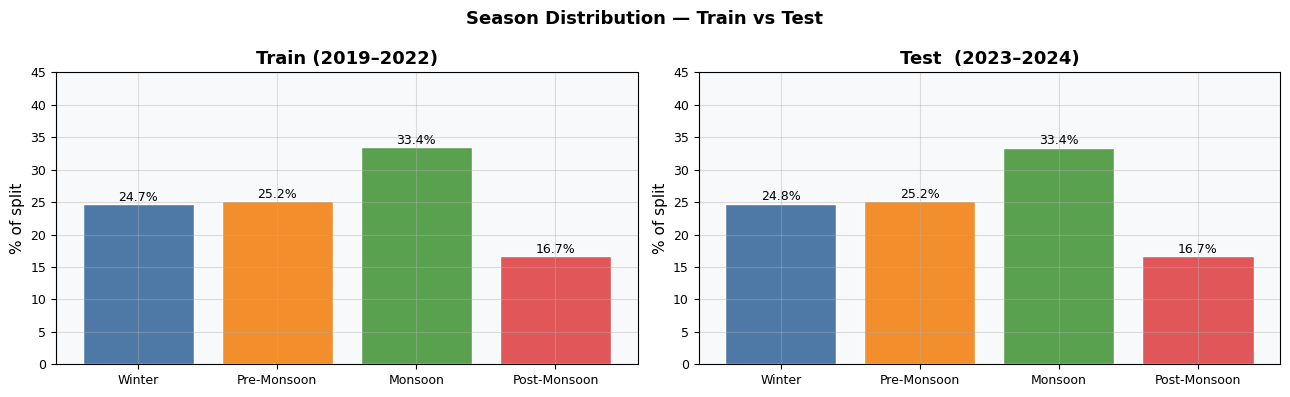

Season proportions (%) — Train vs Test:
Season              Train     Test
----------------------------------
Winter              24.7%    24.8%
Pre-Monsoon         25.2%    25.2%
Monsoon             33.4%    33.4%
Post-Monsoon        16.7%    16.7%


In [91]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (label, subset) in zip(axes, [('Train (2019–2022)', train_df),
                                        ('Test  (2023–2024)', test_df)]):
    season_pct = (
        subset.groupby('SEASON')[TARGET]
        .count()
        .reindex(SEASON_ORDER)
        / len(subset) * 100
    )
    colors = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759']
    bars = ax.bar(season_pct.index, season_pct.values, color=colors, edgecolor='white')
    for bar, val in zip(bars, season_pct.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
                f'{val:.1f}%', ha='center', fontsize=9)
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('% of split')
    ax.set_ylim(0, 45)

plt.suptitle('Season Distribution — Train vs Test', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'split_season_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

# Statistical check
print('Season proportions (%) — Train vs Test:')
print(f'{"Season":<16} {"Train":>8} {"Test":>8}')
print('-' * 34)
for season in SEASON_ORDER:
    tr_pct = (train_df['SEASON'] == season).mean() * 100
    te_pct = (test_df['SEASON'] == season).mean() * 100
    flag = '  ⚠' if abs(tr_pct - te_pct) > 5 else ''
    print(f'{season:<16} {tr_pct:>7.1f}% {te_pct:>7.1f}%{flag}')


## Cell 8 — StandardScaler

### Why scale?

| Model | Needs scaling? | Reason |
|-------|---------------|--------|
| Linear Regression | Yes | Coefficient magnitude depends on feature scale |
| Ridge Regression | **Critical** | Penalty term treats all features equally only if scaled |
| Random Forest | Not needed | Tree splits are scale-invariant |
| XGBoost | Not needed | Same as Random Forest |
| SVM (future) | **Critical** | RBF kernel is distance-based |

We scale anyway for all models to ensure fair feature importance comparison.

**Critical rule:** The scaler is **fit on the training set only**. Fitting on the full dataset would leak test-set statistics into training — a form of data leakage.


In [92]:
# ── Fit scaler on TRAIN only ──────────────────────────────────────────────
scaler = StandardScaler()

X_train = train_df[FEATURES_EXTENDED].values
X_test  = test_df[FEATURES_EXTENDED].values
y_train = train_df[TARGET].values
y_test  = test_df[TARGET].values

X_train_scaled = scaler.fit_transform(X_train)   # fit + transform
X_test_scaled  = scaler.transform(X_test)        # transform ONLY — no fit

print('Scaler fit on training set only ✓')
print(f'  X_train shape : {X_train_scaled.shape}')
print(f'  X_test  shape : {X_test_scaled.shape}')
print(f'  y_train shape : {y_train.shape}')
print(f'  y_test  shape : {y_test.shape}')
print()
print('Scaler parameters (learned from train only):')
scaler_df = pd.DataFrame({
    'Feature': FEATURES_EXTENDED,
    'Train_Mean': scaler.mean_.round(4),
    'Train_Std':  np.sqrt(scaler.var_).round(4)
})
print(scaler_df.to_string(index=False))


Scaler fit on training set only ✓
  X_train shape : (21900, 31)
  X_test  shape : (10965, 31)
  y_train shape : (21900,)
  y_test  shape : (10965,)

Scaler parameters (learned from train only):
         Feature  Train_Mean  Train_Std
         T2M_MAX     31.1805     5.2968
      TEMP_RANGE     10.2515     4.7124
            RH2M     67.2196    20.5398
              PS     97.5870     2.7552
           WS10M      3.1643     1.3485
       CLOUD_AMT     53.6822    34.1919
      log1p_PREC      0.8973     1.1640
      WIND_CLOUD    181.1808   164.2913
       MONTH_SIN     -0.0051     0.7059
       MONTH_COS     -0.0026     0.7083
      IS_MONSOON      0.3342     0.4717
     DAY_OF_YEAR    183.2500   105.3669
        GHI_LAG1      4.9658     1.4425
       RH2M_LAG1     67.2045    20.5537
      CLOUD_LAG1     53.6839    34.1914
   GHI_7DAY_MEAN      4.9666     1.1964
  CITY_Ahmedabad      0.0667     0.2494
  CITY_Bengaluru      0.0667     0.2494
     CITY_Bhopal      0.0667     0.2494
CITY_B

## Cell 9 — Verify Scaling: Before vs After Distributions

After scaling every feature should have mean ≈ 0 and std ≈ 1 (on the training set). We verify this visually.

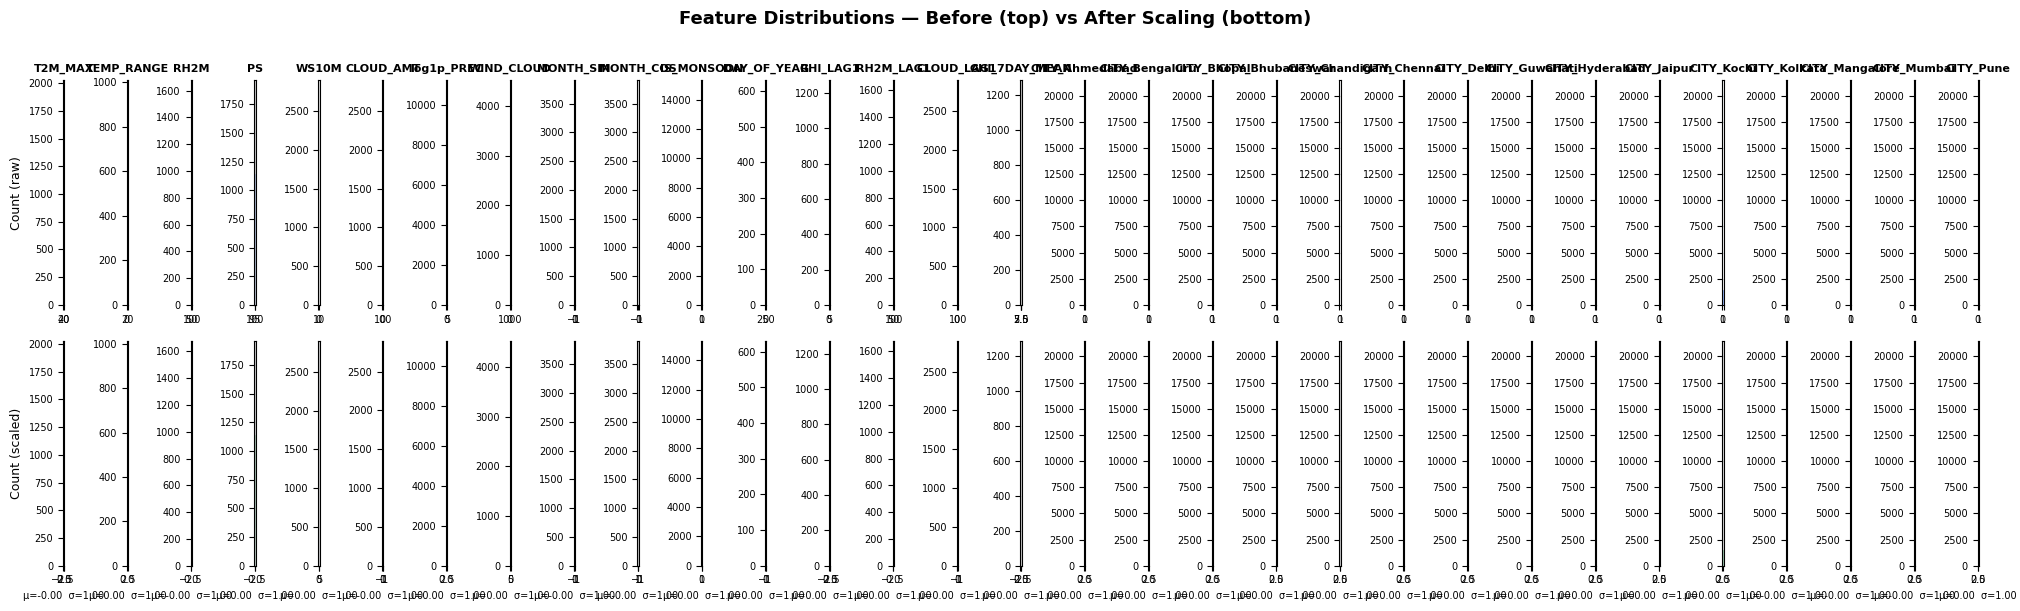

Mean and std after scaling (training set):
  T2M_MAX           mean=-0.0000  std=1.0000
  TEMP_RANGE        mean=+0.0000  std=1.0000
  RH2M              mean=-0.0000  std=1.0000
  PS                mean=+0.0000  std=1.0000
  WS10M             mean=+0.0000  std=1.0000
  CLOUD_AMT         mean=-0.0000  std=1.0000
  log1p_PREC        mean=+0.0000  std=1.0000
  WIND_CLOUD        mean=+0.0000  std=1.0000
  MONTH_SIN         mean=-0.0000  std=1.0000
  MONTH_COS         mean=-0.0000  std=1.0000
  IS_MONSOON        mean=+0.0000  std=1.0000
  DAY_OF_YEAR       mean=+0.0000  std=1.0000
  GHI_LAG1          mean=+0.0000  std=1.0000
  RH2M_LAG1         mean=+0.0000  std=1.0000
  CLOUD_LAG1        mean=+0.0000  std=1.0000
  GHI_7DAY_MEAN     mean=+0.0000  std=1.0000
  CITY_Ahmedabad    mean=+0.0000  std=1.0000
  CITY_Bengaluru    mean=+0.0000  std=1.0000
  CITY_Bhopal       mean=+0.0000  std=1.0000
  CITY_Bhubaneswar  mean=+0.0000  std=1.0000
  CITY_Chandigarh   mean=+0.0000  std=1.0000
  CITY_Chenn

In [93]:
fig, axes = plt.subplots(2, len(FEATURES_EXTENDED), figsize=(20, 6))
fig.suptitle('Feature Distributions — Before (top) vs After Scaling (bottom)',
             fontsize=13, fontweight='bold', y=1.01)

for i, feat in enumerate(FEATURES_EXTENDED):
    # Before
    axes[0, i].hist(train_df[feat].dropna(), bins=40,
                    color=PALETTE, alpha=0.7, edgecolor='white', linewidth=0.3)
    axes[0, i].set_title(feat, fontsize=8, fontweight='bold')
    axes[0, i].tick_params(labelsize=7)

    # After
    axes[1, i].hist(X_train_scaled[:, i], bins=40,
                    color='#16a34a', alpha=0.7, edgecolor='white', linewidth=0.3)
    axes[1, i].tick_params(labelsize=7)
    axes[1, i].set_xlabel(f'μ={X_train_scaled[:,i].mean():.2f}  σ={X_train_scaled[:,i].std():.2f}',
                          fontsize=7)

axes[0, 0].set_ylabel('Count (raw)', fontsize=9)
axes[1, 0].set_ylabel('Count (scaled)', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'scaling_before_after.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Mean and std after scaling (training set):')
for i, feat in enumerate(FEATURES_EXTENDED):
    m = X_train_scaled[:, i].mean()
    s = X_train_scaled[:, i].std()
    print(f'  {feat:<16}  mean={m:+.4f}  std={s:.4f}')


## Cell 10 — Also Prepare Core Feature Arrays

We create both Core and Extended arrays so downstream notebooks can choose:
- `FEATURES_CORE` for interpretable baselines
- `FEATURES_EXTENDED` for full-context models


In [94]:
scaler_core = StandardScaler()

X_train_core = train_df[FEATURES_CORE].values
X_test_core  = test_df[FEATURES_CORE].values

X_train_core_scaled = scaler_core.fit_transform(X_train_core)
X_test_core_scaled  = scaler_core.transform(X_test_core)

print(f'Core arrays:')
print(f'  X_train_core_scaled : {X_train_core_scaled.shape}')
print(f'  X_test_core_scaled  : {X_test_core_scaled.shape}')
print()
print(f'Extended arrays:')
print(f'  X_train_scaled      : {X_train_scaled.shape}')
print(f'  X_test_scaled       : {X_test_scaled.shape}')


Core arrays:
  X_train_core_scaled : (21900, 8)
  X_test_core_scaled  : (10965, 8)

Extended arrays:
  X_train_scaled      : (21900, 31)
  X_test_scaled       : (10965, 31)


## Cell 11 — Target Variable Analysis

Before modelling we verify the target (`ALLSKY_SFC_SW_DWN`) distribution in train and test sets. A large shift between train and test would mean the split is not representative.

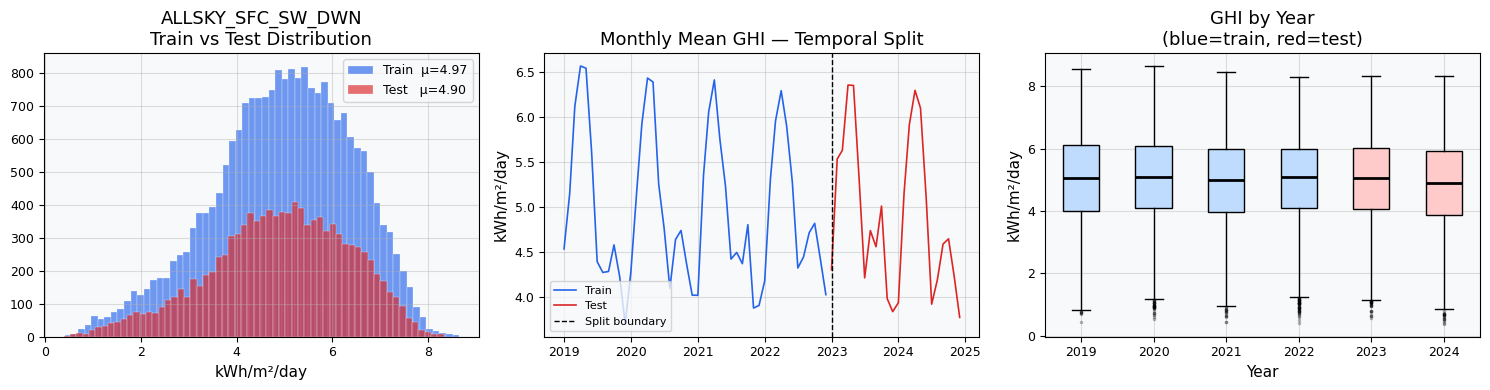

Target statistics:
  Train  — mean: 4.9656  std: 1.4426  min: 0.41  max: 8.65
  Test   — mean: 4.9007  std: 1.4454  min: 0.38  max: 8.33
  Mean shift     : 0.0649 kWh/m²/day ✓ acceptable


In [95]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution comparison
axes[0].hist(y_train, bins=60, alpha=0.65, color='#2563eb',
             edgecolor='white', linewidth=0.3, label=f'Train  μ={y_train.mean():.2f}')
axes[0].hist(y_test, bins=60, alpha=0.65, color='#dc2626',
             edgecolor='white', linewidth=0.3, label=f'Test   μ={y_test.mean():.2f}')
axes[0].set_title(f'{TARGET}\nTrain vs Test Distribution')
axes[0].set_xlabel('kWh/m²/day')
axes[0].legend(fontsize=9)

# Time series of monthly mean
df_work['ym'] = df_work['date'].dt.to_period('M')
monthly = df_work.groupby(['ym', 'YEAR_NUM'])[TARGET].mean().reset_index()
monthly['ym_dt'] = monthly['ym'].dt.to_timestamp()

axes[1].plot(monthly[monthly['YEAR_NUM'].isin(TRAIN_YEARS)]['ym_dt'],
             monthly[monthly['YEAR_NUM'].isin(TRAIN_YEARS)][TARGET],
             color='#2563eb', linewidth=1.2, label='Train')
axes[1].plot(monthly[monthly['YEAR_NUM'].isin(TEST_YEARS)]['ym_dt'],
             monthly[monthly['YEAR_NUM'].isin(TEST_YEARS)][TARGET],
             color='#dc2626', linewidth=1.2, label='Test')
axes[1].axvline(pd.Timestamp('2023-01-01'), color='black',
                linestyle='--', linewidth=1, label='Split boundary')
axes[1].set_title('Monthly Mean GHI — Temporal Split')
axes[1].set_ylabel('kWh/m²/day')
axes[1].legend(fontsize=8)

# Boxplot by year
years_data = [df_work[df_work['YEAR_NUM'] == y][TARGET].values for y in range(2019, 2025)]
bp = axes[2].boxplot(years_data, labels=range(2019, 2025), patch_artist=True,
                      medianprops=dict(color='black', linewidth=2),
                      flierprops=dict(marker='o', markersize=1.5, alpha=0.3))
for i, (patch, year) in enumerate(zip(bp['boxes'], range(2019, 2025))):
    patch.set_facecolor('#bfdbfe' if year <= 2022 else '#fecaca')
axes[2].set_title('GHI by Year\n(blue=train, red=test)')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('kWh/m²/day')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'target_split_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Target statistics:')
print(f'  Train  — mean: {y_train.mean():.4f}  std: {y_train.std():.4f}  '
      f'min: {y_train.min():.2f}  max: {y_train.max():.2f}')
print(f'  Test   — mean: {y_test.mean():.4f}  std: {y_test.std():.4f}  '
      f'min: {y_test.min():.2f}  max: {y_test.max():.2f}')
mean_shift = abs(y_train.mean() - y_test.mean())
print(f'  Mean shift     : {mean_shift:.4f} kWh/m²/day', '✓ acceptable' if mean_shift < 0.3 else '⚠ large — check split')


## Cell 12 — Feature Correlation with Target (Engineered Set)

After engineering, we recheck how each feature correlates with `ALLSKY_SFC_SW_DWN`.
This gives a quick sanity check that engineered features (TEMP_RANGE, log1p_PREC, IS_MONSOON)
have the expected direction and strength.


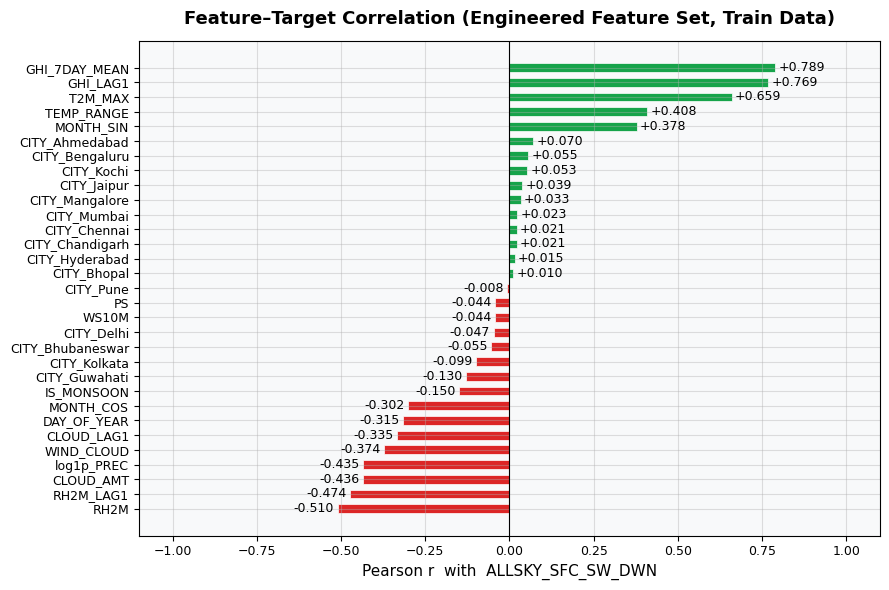

Top positive predictors:
GHI_7DAY_MEAN      0.788815
GHI_LAG1           0.768871
T2M_MAX            0.659294
TEMP_RANGE         0.408138
MONTH_SIN          0.377836
CITY_Ahmedabad     0.069637
CITY_Bengaluru     0.054556
CITY_Kochi         0.053181
CITY_Jaipur        0.038610
CITY_Mangalore     0.033051
CITY_Mumbai        0.022998
CITY_Chennai       0.020944
CITY_Chandigarh    0.020920
CITY_Hyderabad     0.015334
CITY_Bhopal        0.010004

Top negative predictors:
RH2M               -0.510385
RH2M_LAG1          -0.473798
CLOUD_AMT          -0.436178
log1p_PREC         -0.434703
WIND_CLOUD         -0.373511
CLOUD_LAG1         -0.335037
DAY_OF_YEAR        -0.315291
MONTH_COS          -0.301560
IS_MONSOON         -0.150302
CITY_Guwahati      -0.130074
CITY_Kolkata       -0.099213
CITY_Bhubaneswar   -0.054749
CITY_Delhi         -0.047278
WS10M              -0.044461
PS                 -0.044013
CITY_Pune          -0.007921


In [96]:
corr_feats = FEATURES_EXTENDED + [TARGET]
corr_vals  = (
    train_df[corr_feats]
    .corr()[TARGET]
    .drop(TARGET)
    .sort_values()
)

colors = ['#dc2626' if v < 0 else '#16a34a' for v in corr_vals]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(corr_vals.index, corr_vals.values, color=colors,
               edgecolor='white', linewidth=0.5, height=0.6)

for bar, val in zip(bars, corr_vals.values):
    ax.text(val + (0.01 if val >= 0 else -0.01),
            bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel(f'Pearson r  with  {TARGET}', fontsize=11)
ax.set_title('Feature–Target Correlation (Engineered Feature Set, Train Data)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(-1.1, 1.1)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'feature_target_correlation_engineered.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print('Top positive predictors:')
print(corr_vals[corr_vals > 0].sort_values(ascending=False).to_string())
print()
print('Top negative predictors:')
print(corr_vals[corr_vals < 0].sort_values().to_string())


## Cell 13 — Save Preprocessed Data to CSV

All downstream notebooks load these files instead of re-running preprocessing.

In [97]:
# Build the save dataframes (unscaled — models can scale themselves or use pre-scaled arrays)
# RISK_LABEL is included so downstream classification notebooks (NB08) can load it directly.
# It is appended after TARGET to clearly separate predictors from targets.
save_cols = (
    ['date', 'city', 'YEAR_NUM', 'MONTH', 'SEASON']
    + FEATURES_EXTENDED
    + [TARGET, 'RISK_LABEL']
)

train_save = train_df[[c for c in save_cols if c in train_df.columns]].copy()
test_save  = test_df[[c for c in save_cols if c in test_df.columns]].copy()

train_path = os.path.join(OUT_DIR, 'train_preprocessed.csv')
test_path  = os.path.join(OUT_DIR, 'test_preprocessed.csv')

train_save.to_csv(train_path, index=False)
test_save.to_csv(test_path, index=False)

print(f'Train saved → {train_path}  ({train_save.shape})')
print(f'Test  saved → {test_path}  ({test_save.shape})')
print()
print(f'Columns saved: {list(train_save.columns)}')
print()
# Confirm RISK_LABEL distribution is preserved in both splits
print('RISK_LABEL in train_save:')
print(train_save['RISK_LABEL'].value_counts().sort_index().to_dict())
print('RISK_LABEL in test_save:')
print(test_save['RISK_LABEL'].value_counts().sort_index().to_dict())

Train saved → ../outputs/train_preprocessed.csv  ((21900, 38))
Test  saved → ../outputs/test_preprocessed.csv  ((10965, 38))

Columns saved: ['date', 'city', 'YEAR_NUM', 'MONTH', 'SEASON', 'T2M_MAX', 'TEMP_RANGE', 'RH2M', 'PS', 'WS10M', 'CLOUD_AMT', 'log1p_PREC', 'WIND_CLOUD', 'MONTH_SIN', 'MONTH_COS', 'IS_MONSOON', 'DAY_OF_YEAR', 'GHI_LAG1', 'RH2M_LAG1', 'CLOUD_LAG1', 'GHI_7DAY_MEAN', 'CITY_Ahmedabad', 'CITY_Bengaluru', 'CITY_Bhopal', 'CITY_Bhubaneswar', 'CITY_Chandigarh', 'CITY_Chennai', 'CITY_Delhi', 'CITY_Guwahati', 'CITY_Hyderabad', 'CITY_Jaipur', 'CITY_Kochi', 'CITY_Kolkata', 'CITY_Mangalore', 'CITY_Mumbai', 'CITY_Pune', 'ALLSKY_SFC_SW_DWN', 'RISK_LABEL']

RISK_LABEL in train_save:
{0: 14799, 1: 6923, 2: 178}
RISK_LABEL in test_save:
{0: 7485, 1: 3429, 2: 51}


## Cell 14 — Save Scaler Objects

The scalers are serialised with `joblib` so Notebooks 07–10 can transform new data consistently without re-fitting.

In [98]:
scaler_core_path = os.path.join(OUT_DIR, 'scaler_core.pkl')
scaler_ext_path  = os.path.join(OUT_DIR, 'scaler_extended.pkl')

joblib.dump(scaler_core, scaler_core_path)
joblib.dump(scaler,      scaler_ext_path)

print(f'Core scaler saved     → {scaler_core_path}')
print(f'Extended scaler saved → {scaler_ext_path}')
print()
print('Usage in downstream notebooks:')
print('  import joblib')
print('  scaler = joblib.load("../outputs/scaler_extended.pkl")')
print('  X_new_scaled = scaler.transform(X_new)')


Core scaler saved     → ../outputs/scaler_core.pkl
Extended scaler saved → ../outputs/scaler_extended.pkl

Usage in downstream notebooks:
  import joblib
  scaler = joblib.load("../outputs/scaler_extended.pkl")
  X_new_scaled = scaler.transform(X_new)


## Cell 15 — Save Feature Config JSON

A machine-readable config file records every preprocessing decision so there is a single source of truth for all downstream notebooks.

In [99]:
import json

config = {
    'target':              TARGET,
    'features_core':       FEATURES_CORE,
    'features_temporal':   FEATURES_TEMPORAL,
    'features_lag':        FEATURES_LAG,
    'features_extended':   FEATURES_EXTENDED,
    'classification_target': 'RISK_LABEL',
    'dropped_from_nb05':   ['T2M', 'T2M_MIN'],
    'engineered': {
        'TEMP_RANGE':     'T2M_MAX - T2M_MIN',
        'log1p_PREC':     'log1p(PRECTOTCORR)',
        'MONTH_SIN':      'sin(2π × MONTH / 12)',
        'MONTH_COS':      'cos(2π × MONTH / 12)',
        'IS_MONSOON':     '1 if SEASON == Monsoon else 0',
        'DAY_OF_YEAR':    'date.dayofyear',
        'WIND_CLOUD':     'WS10M × CLOUD_AMT',
        'GHI_LAG1':       'groupby(city)[GHI].shift(1)',
        'RH2M_LAG1':      'groupby(city)[RH2M].shift(1)',
        'CLOUD_LAG1':     'groupby(city)[CLOUD_AMT].shift(1)',
        'GHI_7DAY_MEAN':  'groupby(city)[GHI].rolling(7, min_periods=1).mean()',
        'RISK_LABEL':     'np.select: 2=Fire Risk, 1=Grid Stress, 0=Normal',
    },
    'risk_label_thresholds': {
        'fire_risk':   'T2M_MAX > 42 AND RH2M < 18 AND ALLSKY_SFC_SW_DWN > 5.5',
        'grid_stress': 'CLOUD_AMT > 80',
        'normal':      'default (0)',
        'ghi_unit':    'kWh/m²/day (NASA POWER) — 5.5 ≈ 650 W/m²',
    },
    'split': {
        'strategy':    'temporal',
        'train_years': TRAIN_YEARS,
        'test_years':  TEST_YEARS,
        'train_rows':  int(len(train_df)),
        'test_rows':   int(len(test_df)),
    },
    'scaling': {
        'class':       'StandardScaler',
        'fit_on':      'train set only',
        'scaler_core': 'outputs/scaler_core.pkl',
        'scaler_ext':  'outputs/scaler_extended.pkl',
    },
    'outliers': 'no rows deleted — outliers carry risk labels (NB05 decision)',
    'lag_nan_rows_dropped': 'one per city (shift(1) first row) — audited in Cell 5b',
}

config_path = os.path.join(OUT_DIR, 'nb06_preprocessing_config.json')
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)

print(f'Config saved → {config_path}')
print(json.dumps(config, indent=2))

Config saved → ../outputs/nb06_preprocessing_config.json
{
  "target": "ALLSKY_SFC_SW_DWN",
  "features_core": [
    "T2M_MAX",
    "TEMP_RANGE",
    "RH2M",
    "PS",
    "WS10M",
    "CLOUD_AMT",
    "log1p_PREC",
    "WIND_CLOUD"
  ],
  "features_temporal": [
    "MONTH_SIN",
    "MONTH_COS",
    "IS_MONSOON",
    "DAY_OF_YEAR"
  ],
  "features_lag": [
    "GHI_LAG1",
    "RH2M_LAG1",
    "CLOUD_LAG1",
    "GHI_7DAY_MEAN"
  ],
  "features_extended": [
    "T2M_MAX",
    "TEMP_RANGE",
    "RH2M",
    "PS",
    "WS10M",
    "CLOUD_AMT",
    "log1p_PREC",
    "WIND_CLOUD",
    "MONTH_SIN",
    "MONTH_COS",
    "IS_MONSOON",
    "DAY_OF_YEAR",
    "GHI_LAG1",
    "RH2M_LAG1",
    "CLOUD_LAG1",
    "GHI_7DAY_MEAN",
    "CITY_Ahmedabad",
    "CITY_Bengaluru",
    "CITY_Bhopal",
    "CITY_Bhubaneswar",
    "CITY_Chandigarh",
    "CITY_Chennai",
    "CITY_Delhi",
    "CITY_Guwahati",
    "CITY_Hyderabad",
    "CITY_Jaipur",
    "CITY_Kochi",
    "CITY_Kolkata",
    "CITY_Mangalore",
    "CI

## Cell 16 — Complete Feature Engineering Summary

### All engineered features at a glance

| Feature | Formula | Physical meaning | In CORE | In EXTENDED |
|---------|---------|-----------------|---------|-------------|
| `TEMP_RANGE` | T2M_MAX − T2M_MIN | Diurnal temp range — DTR | ✓ | ✓ |
| `log1p_PREC` | log(1 + PRECTOTCORR) | Normalised precipitation | ✓ | ✓ |
| `WIND_CLOUD` | WS10M × CLOUD_AMT | Wind–cloud interaction | ✓ | ✓ |
| `MONTH_SIN` | sin(2π × MONTH / 12) | Cyclical month position | — | ✓ |
| `MONTH_COS` | cos(2π × MONTH / 12) | Cyclical month position | — | ✓ |
| `IS_MONSOON` | 1 if Jun–Sep else 0 | Binary monsoon indicator | — | ✓ |
| `DAY_OF_YEAR`| date.dayofyear | Fine-grained temporal | — | ✓ |
| `GHI_LAG1` | city-wise shift(1) on GHI | Yesterday's radiation | — | ✓ |
| `RH2M_LAG1` | city-wise shift(1) on RH2M | Yesterday's humidity | — | ✓ |
| `CLOUD_LAG1` | city-wise shift(1) on CLOUD_AMT | Yesterday's cloud cover | — | ✓ |
| `GHI_7DAY_MEAN` | city-wise rolling(7).mean() | 7-day radiation trend | — | ✓ |

### Classification target (separate from feature lists)

| Column | Values | Role |
|--------|--------|------|
| `RISK_LABEL` | 0=Normal, 1=Grid Stress, 2=Fire Risk | Classification target for NB08 |

### Dropped features and reasons

| Dropped | Reason |
|---------|--------|
| `T2M` | VIF infinite in all sets — arithmetic mean of T2M_MAX and T2M_MIN |
| `T2M_MIN` | VIF infinite in Set B — collinear with T2M_MAX and TEMP_RANGE together |
| `PRECTOTCORR` (raw) | Replaced by `log1p_PREC` due to extreme right skew |

### What goes into Notebook 07 (regression) and 08 (classification)

```python
# Load these in NB07 / NB08:
import json, joblib, pandas as pd

train_df = pd.read_csv('../outputs/train_preprocessed.csv', parse_dates=['date'])
test_df  = pd.read_csv('../outputs/test_preprocessed.csv',  parse_dates=['date'])
scaler   = joblib.load('../outputs/scaler_extended.pkl')

config   = json.load(open('../outputs/nb06_preprocessing_config.json'))
FEATURES_CORE     = config['features_core']
FEATURES_EXTENDED = config['features_extended']
TARGET            = config['target']          # regression target

# For classification only:
y_train_cls = train_df['RISK_LABEL'].values
y_test_cls  = test_df['RISK_LABEL'].values
```

In [100]:
# Final verification printout
print('=' * 65)
print('  NOTEBOOK 06 COMPLETE — PREPROCESSING SUMMARY')
print('=' * 65)

print(f'\n  Rows in train set      : {len(train_df):,}')
print(f'  Rows in test set       : {len(test_df):,}')
print(f'  Core features          : {len(FEATURES_CORE)}')
print(f'  Temporal features      : {len(FEATURES_TEMPORAL)}')
print(f'  Lag & rolling features : {len(FEATURES_LAG)}')
print(f'  City one-hot features  : {len(CITY_FEATURES)}')
print(f'  Extended total         : {len(FEATURES_EXTENDED)}')
print(f'  Classification target  : RISK_LABEL (not in feature lists)')
print()

# Feature list verification
assert 'WIND_CLOUD'    in FEATURES_CORE,     'WIND_CLOUD missing from FEATURES_CORE'
assert 'GHI_LAG1'      in FEATURES_LAG,      'GHI_LAG1 missing from FEATURES_LAG'
assert 'RH2M_LAG1'     in FEATURES_LAG,      'RH2M_LAG1 missing from FEATURES_LAG'
assert 'CLOUD_LAG1'    in FEATURES_LAG,      'CLOUD_LAG1 missing from FEATURES_LAG'
assert 'GHI_7DAY_MEAN' in FEATURES_LAG,      'GHI_7DAY_MEAN missing from FEATURES_LAG'
assert 'RISK_LABEL'    not in FEATURES_CORE, 'RISK_LABEL must not be in FEATURES_CORE'
assert 'RISK_LABEL'    not in FEATURES_EXTENDED, 'RISK_LABEL must not be in FEATURES_EXTENDED'
assert 'T2M_MIN'       not in FEATURES_EXTENDED, 'T2M_MIN must not be in FEATURES_EXTENDED'
print('  All feature list assertions passed ✓')
print()

print('  Output files:')
for fname in [
    'train_preprocessed.csv',
    'test_preprocessed.csv',
    'scaler_core.pkl',
    'scaler_extended.pkl',
    'nb06_preprocessing_config.json',
    'prec_log_transform.png',
    'month_cyclical_encoding.png',
    'split_season_distribution.png',
    'scaling_before_after.png',
    'target_split_analysis.png',
    'feature_target_correlation_engineered.png',
]:
    fpath = os.path.join(OUT_DIR, fname)
    exists = '✓' if os.path.exists(fpath) else '✗ (created on run)'
    print(f'    {exists}  outputs/{fname}')

print()
print('  What goes into NB07 / NB08:')
print('  ┌──────────────────────────────────────────────────────────────┐')
print('  │  Regression (NB07, NB08 XGBoost):                           │')
print('  │    y  = ALLSKY_SFC_SW_DWN  (continuous)                     │')
print('  │    X  = FEATURES_EXTENDED  (all engineered predictors)      │')
print('  │                                                              │')
print('  │  Classification (NB08 SVM / RF):                            │')
print('  │    y  = RISK_LABEL         (0=Normal, 1=Grid, 2=Fire)       │')
print('  │    X  = FEATURES_EXTENDED  (same predictors)                │')
print('  └──────────────────────────────────────────────────────────────┘')
print()
print('  Next → 07_regression_models.ipynb')
print('         Linear Regression · Ridge Regression · Random Forest')

  NOTEBOOK 06 COMPLETE — PREPROCESSING SUMMARY

  Rows in train set      : 21,900
  Rows in test set       : 10,965
  Core features          : 8
  Temporal features      : 4
  Lag & rolling features : 4
  City one-hot features  : 15
  Extended total         : 31
  Classification target  : RISK_LABEL (not in feature lists)

  All feature list assertions passed ✓

  Output files:
    ✓  outputs/train_preprocessed.csv
    ✓  outputs/test_preprocessed.csv
    ✓  outputs/scaler_core.pkl
    ✓  outputs/scaler_extended.pkl
    ✓  outputs/nb06_preprocessing_config.json
    ✓  outputs/prec_log_transform.png
    ✓  outputs/month_cyclical_encoding.png
    ✓  outputs/split_season_distribution.png
    ✓  outputs/scaling_before_after.png
    ✓  outputs/target_split_analysis.png
    ✓  outputs/feature_target_correlation_engineered.png

  What goes into NB07 / NB08:
  ┌──────────────────────────────────────────────────────────────┐
  │  Regression (NB07, NB08 XGBoost):                           │
  │ 